# Notebook 3: Crime Trend Forecasting
## Linear Regression with Temporal Train/Test Split

**Purpose:** Build a supervised regression model to predict monthly crime counts  
for each Local Authority area, evaluate on a held-out time period, and project  
3 months into the future with confidence intervals.

**Why this matters for the project:**  
- Introduces a **supervised regression** task (distinct from classification in NB1  
  and unsupervised anomaly detection in NB2)  
- Uses a **temporal train/test split** — the correct approach for time series  
  (never shuffle temporal data, as future data must not leak into training)  
- Produces **actionable predictions** — "crime in Leeds is expected to be X±Y  
  next month" — directly useful for the civilian decision-support use case  
- Measurable accuracy with MAE and RMSE

**Methods:** Linear Regression, Polynomial Regression (degree 2) for comparison  
**Train period:** Jan–Oct 2024 (months 1–10)  
**Test period:** Nov–Dec 2024 (months 11–12)  
**Projection:** 3 months ahead (Jan–Mar 2025) with 95% confidence intervals

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

ACCENT = '#3ecfcf'
CORAL  = '#f06060'
SAGE   = '#4caf7d'
GOLD   = '#f0b429'

print("All imports loaded successfully.")

All imports loaded successfully.


## 2. Load and Explore Data

In [ ]:
from settings import PROCESSED_DIR, LA_NAME_MAP

# Load monthly crime data
monthly = pd.read_parquet(PROCESSED_DIR / "crime_monthly.parquet")
print(f"Loaded: {len(monthly)} rows (expected: 15 areas × 12 months = 180)")
print(f"Columns: {list(monthly.columns)}")

# Add LA names
monthly['la_name'] = monthly['la_code'].map(LA_NAME_MAP)

# Sort by area and month
monthly = monthly.sort_values(['la_code', 'month']).reset_index(drop=True)

#  Create month index (0-11) for regression
# Sorted month strings become indices: 2024-01 → 0, 2024-02 → 1, ..., 2024-12 → 11
month_order = sorted(monthly['month'].unique())
month_to_idx = {m: i for i, m in enumerate(month_order)}
monthly['month_idx'] = monthly['month'].map(month_to_idx)

print(f"\nMonth mapping:")
for m, i in month_to_idx.items():
    print(f"  {m} → {i}")

print(f"\nAreas: {monthly['la_name'].nunique()}")
print(f"Months per area:")
print(monthly.groupby('la_name')['month'].count().to_string())

Loaded: 180 rows (expected: 15 areas × 12 months = 180)
Columns: ['la_code', 'month', 'total_crimes', 'violent_count', 'property_count', 'violent_share', 'property_share']

Month mapping:
  2024-01 → 0
  2024-02 → 1
  2024-03 → 2
  2024-04 → 3
  2024-05 → 4
  2024-06 → 5
  2024-07 → 6
  2024-08 → 7
  2024-09 → 8
  2024-10 → 9
  2024-11 → 10
  2024-12 → 11

Areas: 15
Months per area:
la_name
Bristol, City of            12
Cardiff                     12
Cornwall                    12
County Durham               12
Coventry                    12
Exeter                      12
Herefordshire, County of    12
Leeds                       12
Leicester                   12
Newcastle upon Tyne         12
North Yorkshire             12
Norwich                     12
Sheffield                   12
Swansea                     12
Wiltshire                   12


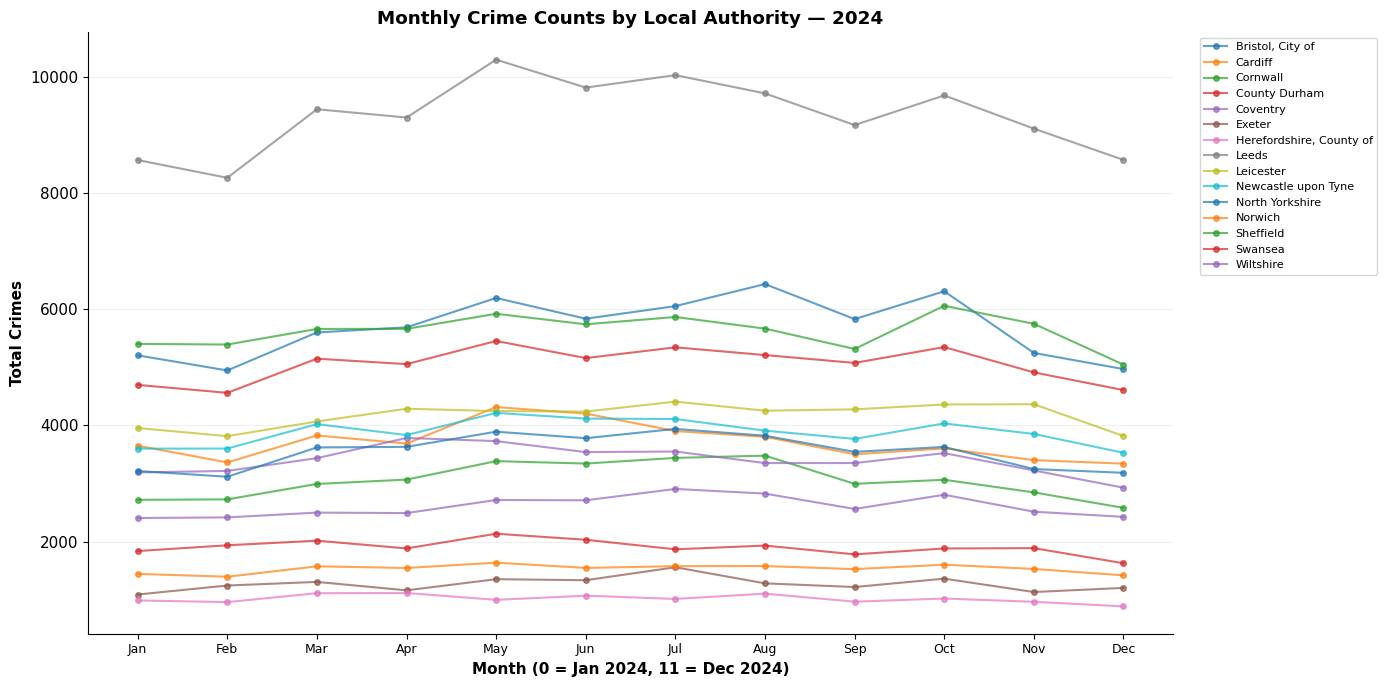

Saved: nb3_crime_trends_all.png


In [ ]:
# Quick look at crime trends
fig, ax = plt.subplots(figsize=(14, 7))

for la_name in sorted(monthly['la_name'].dropna().unique()):
    la_data = monthly[monthly['la_name'] == la_name].sort_values('month_idx')
    ax.plot(la_data['month_idx'], la_data['total_crimes'],
            marker='o', markersize=4, linewidth=1.5, alpha=0.7, label=la_name)

ax.set_xlabel('Month (0 = Jan 2024, 11 = Dec 2024)', fontweight='bold')
ax.set_ylabel('Total Crimes', fontweight='bold')
ax.set_title('Monthly Crime Counts by Local Authority — 2024', fontweight='bold')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb3_crime_trends_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb3_crime_trends_all.png")

## 3. Temporal Train/Test Split

**Critical:** Time series data must never be shuffled. We use the first 10 months  
(Jan–Oct) for training and hold out the last 2 months (Nov–Dec) for testing.  
This simulates the real-world scenario: the model has only seen past data  
when it makes predictions about the future.

**Why not random 80/20 split?**  
Random splitting allows future information to leak into training (e.g., the model  
could train on December data and predict October). This would inflate accuracy  
and produce misleading results. Temporal splits are the only valid approach  
for time-dependent data.

In [ ]:
# Define split
TRAIN_MONTHS = 10   # Jan (0) to Oct (9)
TEST_MONTHS  = 2    # Nov (10) and Dec (11)
PROJECT_MONTHS = 3  # Jan, Feb, Mar 2025 → indices 12, 13, 14

print(f"Training:   months 0–{TRAIN_MONTHS-1} (Jan–Oct 2024)")
print(f"Testing:    months {TRAIN_MONTHS}–{TRAIN_MONTHS+TEST_MONTHS-1} (Nov–Dec 2024)")
print(f"Projection: months {TRAIN_MONTHS+TEST_MONTHS}–{TRAIN_MONTHS+TEST_MONTHS+PROJECT_MONTHS-1} (Jan–Mar 2025)")

Training:   months 0–9 (Jan–Oct 2024)
Testing:    months 10–11 (Nov–Dec 2024)
Projection: months 12–14 (Jan–Mar 2025)


## 4. Linear Regression Forecasting

For each LA, we fit a simple linear regression:

**y = β₀ + β₁·x**

where y is the monthly crime count and x is the month index. The slope β₁  
represents the average change in crimes per month — positive means worsening,  
negative means improving.

**Confidence intervals** are calculated using the prediction standard error:  
SE_pred = s · √(1 + 1/n + (x_new − x̄)² / Σ(xᵢ − x̄)²)  
where s is the residual standard deviation from training data.  
The 95% CI is: ŷ ± t_{0.025, n-2} · SE_pred

In [ ]:
def forecast_area(area_data, train_months=10, project_months=3, confidence=0.95):

    area_data = area_data.sort_values('month_idx').reset_index(drop=True)
    la_name = area_data['la_name'].iloc[0]

    # Split 
    train = area_data[area_data['month_idx'] < train_months]
    test  = area_data[area_data['month_idx'] >= train_months]

    if len(train) < 3:
        return None, None  # Not enough training data

    X_train = train[['month_idx']].values
    y_train = train['total_crimes'].values
    X_test  = test[['month_idx']].values
    y_test  = test['total_crimes'].values

    # Fit linear regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    slope = model.coef_[0]
    intercept = model.intercept_

    # Evaluate on test set
    y_pred_test = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred_test) if len(y_test) > 0 else None
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test)) if len(y_test) > 0 else None

    # Determine trend direction
    if slope > 0.5:
        trend = 'Increasing'
    elif slope < -0.5:
        trend = 'Decreasing'
    else:
        trend = 'Flat'

    # Training residuals for confidence intervals
    y_pred_train = model.predict(X_train)
    residuals = y_train - y_pred_train
    n = len(X_train)
    s = np.std(residuals, ddof=2)  # Residual standard deviation (n-2 degrees of freedom)
    x_mean = X_train.mean()
    x_ss = np.sum((X_train - x_mean) ** 2)

    # t-value for 95% confidence
    alpha = 1 - confidence
    t_val = stats.t.ppf(1 - alpha / 2, df=max(n - 2, 1))

    # Project forward
    projections = []
    total_months = train_months + len(y_test)
    for ahead in range(1, project_months + 1):
        x_new = total_months + ahead - 1  # month index
        y_new = model.predict([[x_new]])[0]

        # Prediction standard error
        se_pred = s * np.sqrt(1 + 1/n + (x_new - x_mean)**2 / max(x_ss, 1e-10))
        ci_half = t_val * se_pred

        projections.append({
            'area': la_name,
            'months_ahead': ahead,
            'month_label': f"2025-{ahead:02d}",
            'predicted_crimes': max(0, round(y_new, 1)),
            'ci_lower': max(0, round(y_new - ci_half, 1)),
            'ci_upper': round(y_new + ci_half, 1),
        })

    metrics = {
        'area': la_name,
        'slope': round(slope, 4),
        'intercept': round(intercept, 2),
        'trend': trend,
        'mae': round(mae, 2) if mae is not None else None,
        'rmse': round(rmse, 2) if rmse is not None else None,
        'train_months': n,
        'test_months': len(y_test),
    }

    return metrics, projections

print("forecast_area() function defined successfully.")

forecast_area() function defined successfully.


In [ ]:
# Run forecasting for all areas
all_metrics = []
all_projections = []
all_train_pred = {}
all_test_pred = {}

for la_name in sorted(monthly['la_name'].dropna().unique()):
    area_data = monthly[monthly['la_name'] == la_name]
    metrics, projections = forecast_area(area_data, train_months=TRAIN_MONTHS,
                                          project_months=PROJECT_MONTHS)
    if metrics:
        all_metrics.append(metrics)
        all_projections.extend(projections)

        # Store predictions for plotting
        area_sorted = area_data.sort_values('month_idx')
        X_all = area_sorted[['month_idx']].values
        model = LinearRegression()
        train_mask = area_sorted['month_idx'] < TRAIN_MONTHS
        model.fit(area_sorted.loc[train_mask, ['month_idx']].values,
                  area_sorted.loc[train_mask, 'total_crimes'].values)
        all_train_pred[la_name] = {
            'months': area_sorted['month_idx'].values,
            'actual': area_sorted['total_crimes'].values,
            'predicted': model.predict(X_all),
            'slope': model.coef_[0],
        }

metrics_df = pd.DataFrame(all_metrics)
proj_df = pd.DataFrame(all_projections)

print(f"Forecasted {len(metrics_df)} areas")
print(f"\nFORECAST METRICS SUMMARY")
print("=" * 70)
print(metrics_df[['area', 'slope', 'trend', 'mae', 'rmse']].to_string(index=False))
print(f"\nOverall mean MAE:  {metrics_df['mae'].mean():.1f}")
print(f"Overall mean RMSE: {metrics_df['rmse'].mean():.1f}")

Forecasted 15 areas

FORECAST METRICS SUMMARY
                    area    slope      trend     mae    rmse
        Bristol, City of 127.2970 Increasing 1463.98 1477.94
                 Cardiff   5.9273 Increasing  449.06  450.31
                Cornwall  51.4364 Increasing  715.52  732.91
           County Durham  62.6545 Increasing  720.33  743.29
                Coventry  15.9212 Increasing  486.43  510.82
                  Exeter  20.1394 Increasing  244.04  245.36
Herefordshire, County of   0.4303       Flat  112.38  119.19
                   Leeds 117.7515 Increasing 1294.21 1335.10
               Leicester  49.4182 Increasing  396.31  496.27
     Newcastle upon Tyne  31.7455 Increasing  420.67  456.73
         North Yorkshire  51.7697 Increasing  713.02  715.36
                 Norwich  14.3455 Increasing  154.77  166.79
               Sheffield  35.3515 Increasing  482.61  607.32
                 Swansea  -7.6667 Decreasing  126.50  178.66
               Wiltshire  45.3939 Incre

## 5. Visualisation

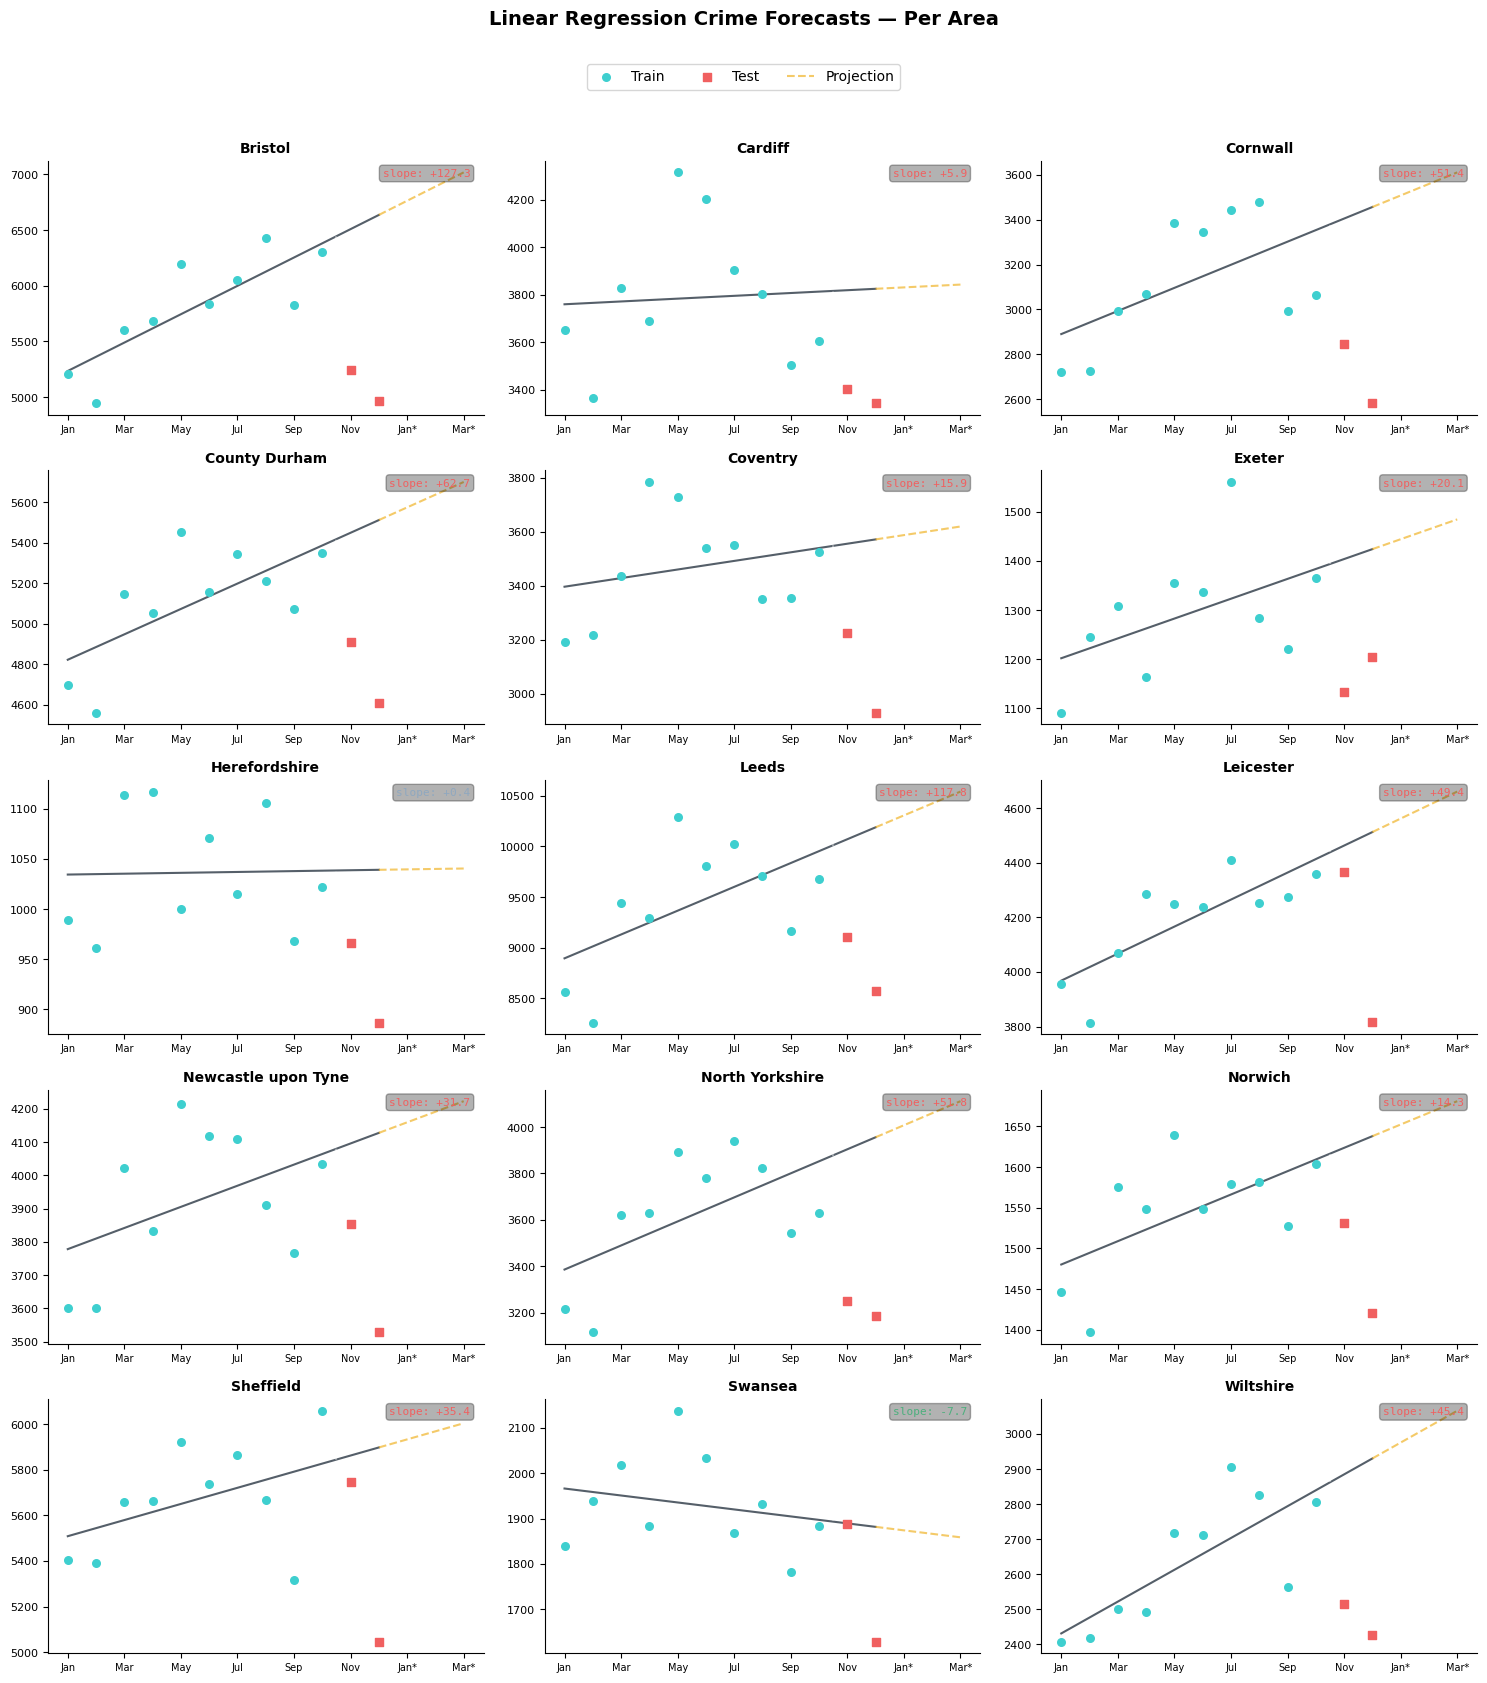

Saved: nb3_forecasts_grid.png


In [ ]:
# Individual area forecasts — grid of subplots
n_areas = len(all_train_pred)
n_cols = 3
n_rows = (n_areas + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.2))
axes = axes.flatten()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec',
                'Jan*','Feb*','Mar*']  # * = projected

for i, (la_name, data) in enumerate(sorted(all_train_pred.items())):
    ax = axes[i]
    months = data['months']
    actual = data['actual']
    predicted = data['predicted']

    # Actual data points
    ax.scatter(months[:TRAIN_MONTHS], actual[:TRAIN_MONTHS],
               c=ACCENT, s=30, zorder=5, label='Train')
    if len(months) > TRAIN_MONTHS:
        ax.scatter(months[TRAIN_MONTHS:], actual[TRAIN_MONTHS:],
                   c=CORAL, s=30, zorder=5, marker='s', label='Test')

    # Regression line (full range including projections)
    x_extended = np.arange(0, 15)  # 0-14 (12 months + 3 projected)
    model_temp = LinearRegression()
    model_temp.fit(months[:TRAIN_MONTHS].reshape(-1, 1), actual[:TRAIN_MONTHS])
    y_extended = model_temp.predict(x_extended.reshape(-1, 1))

    ax.plot(x_extended[:12], y_extended[:12], color='#0d1b2a',
            linewidth=1.5, linestyle='-', alpha=0.7)
    ax.plot(x_extended[11:], y_extended[11:], color=GOLD,
            linewidth=1.5, linestyle='--', alpha=0.7, label='Projection')

    # Train/test divider
    ax.axvline(x=TRAIN_MONTHS - 0.5, color='white', linestyle=':', alpha=0.4)

    slope = data['slope']
    color = CORAL if slope > 0.5 else SAGE if slope < -0.5 else '#8fa8c0'
    ax.set_title(f"{la_name.split(',')[0]}", fontweight='bold', fontsize=10)
    ax.text(0.97, 0.97, f"slope: {slope:+.1f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=color, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3))

    ax.set_xticks(range(0, 15, 2))
    ax.set_xticklabels([month_labels[j] for j in range(0, 15, 2)], fontsize=7)
    ax.tick_params(axis='y', labelsize=8)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Linear Regression Crime Forecasts — Per Area',
             fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb3_forecasts_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb3_forecasts_grid.png")

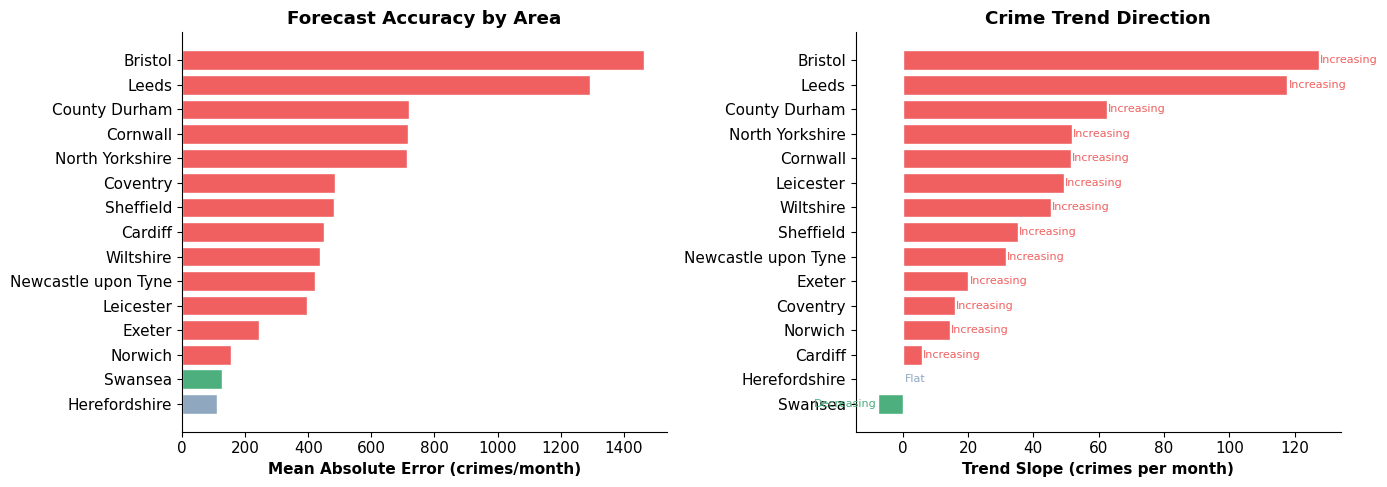

Saved: nb3_mae_and_slopes.png


In [ ]:
# MAE comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by area
metrics_sorted = metrics_df.sort_values('mae', ascending=True)
colors = [CORAL if t == 'Increasing' else SAGE if t == 'Decreasing' else '#8fa8c0'
          for t in metrics_sorted['trend']]
axes[0].barh(metrics_sorted['area'].apply(lambda x: x.split(',')[0]),
             metrics_sorted['mae'], color=colors, edgecolor='white')
axes[0].set_xlabel('Mean Absolute Error (crimes/month)', fontweight='bold')
axes[0].set_title('Forecast Accuracy by Area', fontweight='bold')

# Slope distribution
slope_sorted = metrics_df.sort_values('slope')
colors2 = [CORAL if s > 0.5 else SAGE if s < -0.5 else '#8fa8c0'
           for s in slope_sorted['slope']]
axes[1].barh(slope_sorted['area'].apply(lambda x: x.split(',')[0]),
             slope_sorted['slope'], color=colors2, edgecolor='white')
axes[1].axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
axes[1].set_xlabel('Trend Slope (crimes per month)', fontweight='bold')
axes[1].set_title('Crime Trend Direction', fontweight='bold')
for i, (_, row) in enumerate(slope_sorted.iterrows()):
    axes[1].text(row['slope'] + (0.3 if row['slope'] >= 0 else -0.3), i,
                 row['trend'], va='center', fontsize=8,
                 ha='left' if row['slope'] >= 0 else 'right',
                 color=CORAL if row['trend'] == 'Increasing' else
                       SAGE if row['trend'] == 'Decreasing' else '#8fa8c0')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb3_mae_and_slopes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb3_mae_and_slopes.png")

## 6. Polynomial Regression Comparison

We also fit a degree-2 polynomial regression to test whether a non-linear  
model captures seasonal curvature that linear regression misses.

**y = β₀ + β₁·x + β₂·x²**

If polynomial regression significantly outperforms linear, it suggests  
the crime trend is non-linear (e.g., seasonal U-shape). If both perform  
similarly, the simpler linear model is preferable (Occam's razor).

In [ ]:
# Polynomial regression comparison
poly_metrics = []

for la_name in sorted(monthly['la_name'].dropna().unique()):
    area_data = monthly[monthly['la_name'] == la_name].sort_values('month_idx')

    train = area_data[area_data['month_idx'] < TRAIN_MONTHS]
    test  = area_data[area_data['month_idx'] >= TRAIN_MONTHS]

    if len(train) < 3 or len(test) == 0:
        continue

    X_train = train[['month_idx']].values
    y_train = train['total_crimes'].values
    X_test  = test[['month_idx']].values
    y_test  = test['total_crimes'].values

    # Polynomial features (degree 2)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)
    y_pred_poly = model_poly.predict(X_test_poly)

    mae_poly  = mean_absolute_error(y_test, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

    poly_metrics.append({
        'area': la_name,
        'mae_poly': round(mae_poly, 2),
        'rmse_poly': round(rmse_poly, 2),
    })

poly_df = pd.DataFrame(poly_metrics)

# Compare linear vs polynomial
comparison = metrics_df[['area', 'mae', 'rmse']].merge(poly_df, on='area')
comparison['mae_improvement'] = comparison['mae'] - comparison['mae_poly']
comparison['better_model'] = comparison['mae_improvement'].apply(
    lambda x: 'Polynomial' if x > 0 else 'Linear' if x < 0 else 'Tie'
)

print("LINEAR vs POLYNOMIAL REGRESSION COMPARISON")
print("=" * 70)
print(comparison[['area', 'mae', 'mae_poly', 'mae_improvement', 'better_model']].to_string(index=False))

linear_wins = (comparison['better_model'] == 'Linear').sum()
poly_wins = (comparison['better_model'] == 'Polynomial').sum()
print(f"\nLinear wins:     {linear_wins}/{len(comparison)}")
print(f"Polynomial wins: {poly_wins}/{len(comparison)}")
print(f"\nMean MAE — Linear: {comparison['mae'].mean():.1f}, Polynomial: {comparison['mae_poly'].mean():.1f}")

LINEAR vs POLYNOMIAL REGRESSION COMPARISON
                    area     mae  mae_poly  mae_improvement better_model
        Bristol, City of 1463.98    961.78           502.20   Polynomial
                 Cardiff  449.06    315.74           133.32   Polynomial
                Cornwall  715.52      5.08           710.44   Polynomial
           County Durham  720.33    247.83           472.50   Polynomial
                Coventry  486.43     54.73           431.70   Polynomial
                  Exeter  244.04     67.84           176.20   Polynomial
Herefordshire, County of  112.38     17.53            94.85   Polynomial
                   Leeds 1294.21    108.97          1185.24   Polynomial
               Leicester  396.31    246.96           149.35   Polynomial
     Newcastle upon Tyne  420.67     74.51           346.16   Polynomial
         North Yorkshire  713.02     88.57           624.45   Polynomial
                 Norwich  154.77     36.26           118.51   Polynomial
        

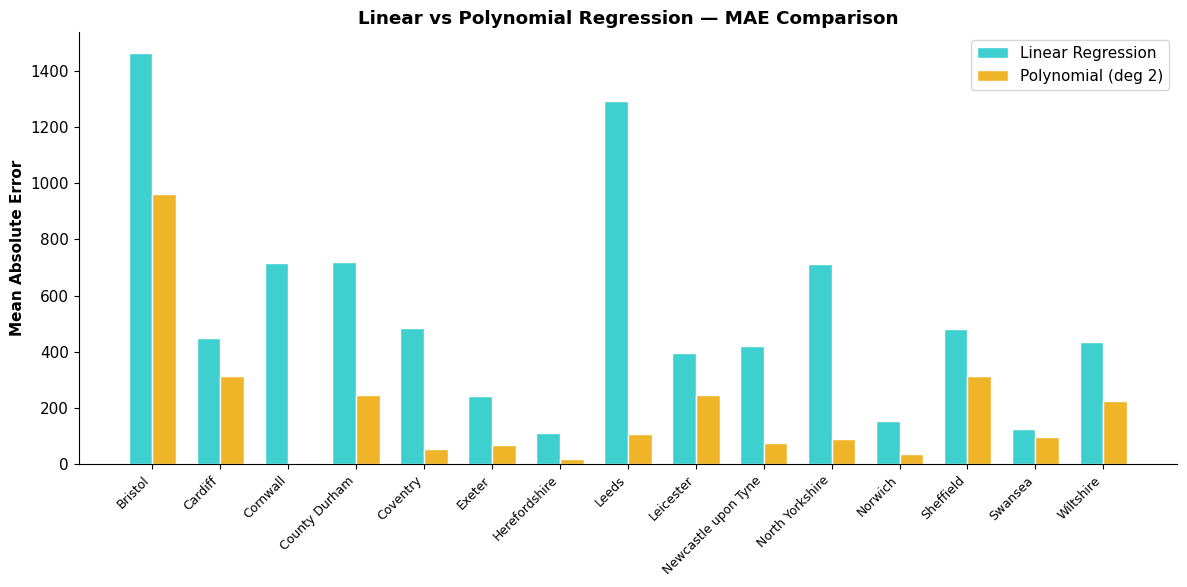

Saved: nb3_linear_vs_poly.png


In [ ]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['mae'], width, label='Linear Regression',
               color=ACCENT, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['mae_poly'], width, label='Polynomial (deg 2)',
               color=GOLD, edgecolor='white')

ax.set_ylabel('Mean Absolute Error', fontweight='bold')
ax.set_title('Linear vs Polynomial Regression — MAE Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([a.split(',')[0] for a in comparison['area']], rotation=45, ha='right', fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb3_linear_vs_poly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb3_linear_vs_poly.png")

## 7. 3-Month Forward Projections

In [ ]:
# Display projections with confidence intervals
print("3-MONTH FORWARD PROJECTIONS (Jan–Mar 2025)")
print("=" * 75)

for la_name in sorted(proj_df['area'].unique()):
    la_proj = proj_df[proj_df['area'] == la_name].sort_values('months_ahead')
    print(f"\n{la_name}:")
    for _, p in la_proj.iterrows():
        print(f"  +{p['months_ahead']}mo ({p['month_label']}): "
              f"{p['predicted_crimes']:.0f} crimes  "
              f"[95% CI: {p['ci_lower']:.0f} – {p['ci_upper']:.0f}]  "
              f"(range: {p['ci_upper'] - p['ci_lower']:.0f})")

print(f"\nNote: Wide confidence intervals are expected — extrapolating from only")
print(f"10 training months introduces substantial uncertainty, which the CIs")
print(f"honestly communicate. This is a known limitation discussed in the report.")

3-MONTH FORWARD PROJECTIONS (Jan–Mar 2025)

Bristol, City of:
  +1mo (2025-01): 6763 crimes  [95% CI: 5869 – 7657]  (range: 1788)
  +2mo (2025-02): 6890 crimes  [95% CI: 5949 – 7832]  (range: 1883)
  +3mo (2025-03): 7018 crimes  [95% CI: 6025 – 8010]  (range: 1984)

Cardiff:
  +1mo (2025-01): 3830 crimes  [95% CI: 2865 – 4796]  (range: 1930)
  +2mo (2025-02): 3836 crimes  [95% CI: 2820 – 4853]  (range: 2033)
  +3mo (2025-03): 3842 crimes  [95% CI: 2771 – 4913]  (range: 2142)

Cornwall:
  +1mo (2025-01): 3508 crimes  [95% CI: 2749 – 4266]  (range: 1517)
  +2mo (2025-02): 3559 crimes  [95% CI: 2760 – 4358]  (range: 1598)
  +3mo (2025-03): 3610 crimes  [95% CI: 2769 – 4452]  (range: 1684)

County Durham:
  +1mo (2025-01): 5574 crimes  [95% CI: 4891 – 6258]  (range: 1367)
  +2mo (2025-02): 5637 crimes  [95% CI: 4917 – 6357]  (range: 1440)
  +3mo (2025-03): 5700 crimes  [95% CI: 4941 – 6458]  (range: 1517)

Coventry:
  +1mo (2025-01): 3587 crimes  [95% CI: 2962 – 4213]  (range: 1251)
  +2mo

## 8. Export for Flask Web Application

Two CSV files are saved, matching the format expected by  
`app.py → _get_area_forecast()` and the Insights page template.

In [ ]:
# 8a. forecast_metrics.csv
#     Columns: area, slope, intercept, trend, mae, rmse, train_months, test_months
out_path = PROCESSED_DIR / 'forecast_metrics.csv'
metrics_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.name}")
print(f"  {len(metrics_df)} areas")
print(metrics_df[['area', 'slope', 'trend', 'mae', 'rmse']].head().to_string(index=False))

Saved: forecast_metrics.csv
  15 areas
            area    slope      trend     mae    rmse
Bristol, City of 127.2970 Increasing 1463.98 1477.94
         Cardiff   5.9273 Increasing  449.06  450.31
        Cornwall  51.4364 Increasing  715.52  732.91
   County Durham  62.6545 Increasing  720.33  743.29
        Coventry  15.9212 Increasing  486.43  510.82


In [ ]:
# 8b. forecast_projections.csv
#     Columns: area, months_ahead, month_label, predicted_crimes, ci_lower, ci_upper
out_path = PROCESSED_DIR / 'forecast_projections.csv'
proj_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.name}")
print(f"  {len(proj_df)} projections ({len(proj_df)//3} areas × 3 months)")

Saved: forecast_projections.csv
  45 projections (15 areas × 3 months)


In [ ]:
# 8c. Verify all output files
expected = ['forecast_metrics.csv', 'forecast_projections.csv']

print("Output file check:")
for fname in expected:
    path = PROCESSED_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

print(f"\n{'='*60}")
print("INTEGRATION COMPLETE")
print(f"{'='*60}")
print("The Insights page will now show:")
print("  • ML·03 forecast metrics table with slope, trend, MAE, RMSE")
print("  • 3-month projections with confidence intervals")
print("  • Mean MAE summary badge")
print("\nThe Area Profile page will now show:")
print("  • Crime Trend Forecast card for each area")
print("  • Training period, MAE, RMSE, slope, direction")
print("  • 3-month projection strip with CI ranges")

Output file check:
  [OK] forecast_metrics.csv
  [OK] forecast_projections.csv

INTEGRATION COMPLETE
The Insights page will now show:
  • ML·03 forecast metrics table with slope, trend, MAE, RMSE
  • 3-month projections with confidence intervals
  • Mean MAE summary badge

The Area Profile page will now show:
  • Crime Trend Forecast card for each area
  • Training period, MAE, RMSE, slope, direction
  • 3-month projection strip with CI ranges
